In [35]:
import os

# 0. VRAM 파편화 완화 (★ torch를 import 하기 전에 설정해야 적용됨)
#    "reserved but unallocated 2.24 GiB" 처럼 잡아만 두고 못 쓰는 조각을 줄여준다.
#    VRAM 8GB 카드에서 VGG16 미세조정을 돌리려면 이 한 줄이 꽤 도움 됨
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import torch

# 1. 기본 디바이스를 CPU로 원복 (데이터 로더 충돌 방지)
torch.set_default_device("cpu")

# 2. Keras 백엔드 설정
os.environ["KERAS_BACKEND"] = "torch"

import keras

print(
    "🚀 사용 중인 GPU:",
    torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",
)
print(f"   VRAM 전체 : {torch.cuda.get_device_properties(0).total_memory/1e9:.2f} GB")

🚀 사용 중인 GPU: NVIDIA GeForce RTX 5060 Ti
   VRAM 전체 : 8.55 GB


In [36]:
import gc, torch
for name in ['mlp_model', 'cnn_model', 'transfer_model']:
    if name in globals():
        del globals()[name]      # 학습곡선 h, h_cnn, h_transfer는 시각화용이라 남김
gc.collect()
torch.cuda.empty_cache()
print(f"GPU 여유 : {torch.cuda.mem_get_info()[0]/1e9:.2f} GB")

GPU 여유 : 7.35 GB


### RNN활용하기 : 네이버영화리뷰데이터 감성분석
- 실제 텍스트 데이터를 전처리하여 RNN계열 모델에 학습시켜보자
- 네이버영화 리뷰 데이터를 이용하여 긍정/부정을 분류하는 감성분석을 해보자

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


### 네이버 영화 리뷰 감성 분류하기
- 총 200,000개 리뷰로 구성된 데이터로, 영화 리뷰에 대한 텍스트와 해당 리뷰가 긍정인 경우 1을, 부정인 경우 0으로 표시된 레이블(라벨)로 구성

In [2]:
train_df = pd.read_csv('data/ratings_train.txt', delimiter='\t')
test_df = pd.read_csv('data/ratings_test.txt', delimiter='\t')

In [3]:
train_df.head()
# id : 리뷰id
# document : 리뷰내용(텍스트)
# label : 긍정여부 클래스(긍정1 부정0)


,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


In [4]:
# 데이터 크기 확인
train_df.shape, test_df.shape

((150000, 3), (50000, 3))

In [5]:
train_df.info()
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   id        150000 non-null  int64 
 1   document  149995 non-null  object
 2   label     150000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 3.4+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        50000 non-null  int64 
 1   document  49997 non-null  object
 2   label     50000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 1.1+ MB


In [6]:
# 결측치가 있는 데이터 확인
train_df.isnull().sum() # 5개
test_df.isnull().sum() # 3개

id          0
document    3
label       0
dtype: int64

In [7]:
train_df[train_df['document'].isnull()]

,id,document,label
25857,2172111,NaN,1
55737,6369843,NaN,1
110014,1034280,NaN,0
126782,5942978,NaN,0
140721,1034283,NaN,0


In [8]:
# 결측치 제거
train_df.dropna(how='any', inplace=True)
test_df.dropna(how='any', inplace=True)

In [11]:
train_df.isnull().sum()

id          0
document    0
label       0
dtype: int64

In [12]:
test_df.isnull().sum()

id          0
document    0
label       0
dtype: int64

<Axes: xlabel='label'>

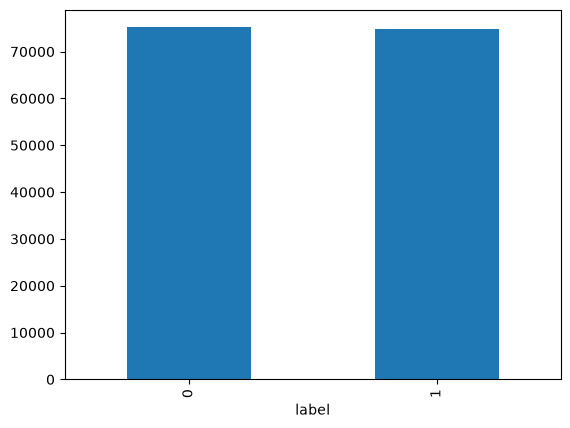

In [13]:
train_df['label'].value_counts().plot(kind='bar')

In [9]:
# document 컬럼 안의 텍스트를 한글과 공백을 제외한 모든 것들은 없애주자!

train_df['document'] = train_df['document'].str.replace("[^가-힣 ]","", regex=True)
test_df['document'] = test_df['document'].str.replace("[^가-힣 ]","", regex=True)

In [10]:
# 훈련용 데이터
train_df['document'].str.strip() != '' # 조건식
# 문자열 양끝의 공백을 제거했을 때 그것이 비어있는 문자열이 아니니?(==문자열이 있니?)
train_df[train_df['document'].str.strip() != '']

# 평가용 데이터
test_df['document'].str.strip() != '' # 조건식
test_df[test_df['document'].str.strip() != '']

,id,document,label
0,6270596,굳,1
2,8544678,뭐야 이 평점들은 나쁘진 않지만 점 짜리는 더더욱 아니잖아,0
3,6825595,지루하지는 않은데 완전 막장임 돈주고 보기에는,0
4,6723715,만 아니었어도 별 다섯 개 줬을텐데 왜 로 나와서 제 심기를 불편하게 하죠,0
5,7898805,음악이 주가 된 최고의 음악영화,1
...,...,...,...
49995,4608761,오랜만에 평점 로긴했네 킹왕짱 쌈뽕한 영화를 만났습니다 강렬하게 육쾌함,1
49996,5308387,의지 박약들이나 하는거다 탈영은 일단 주인공 김대희 닮았고 이등병 찐따,0
49997,9072549,그림도 좋고 완성도도 높았지만 보는 내내 불안하게 만든다,0
49998,5802125,절대 봐서는 안 될 영화 재미도 없고 기분만 잡치고 한 세트장에서 다 해먹네,0


In [11]:
# 문제와 정답 분리
# 훈련용 문제
X_train = train_df['document']
# 훈련용 정답
y_train = train_df['label']

# 평가용 문제
X_test = test_df['document']
# 평가용 정답
y_test = test_df['label']

# 크기확인
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(149995,) (149995,)
(49997,) (49997,)


### 토큰화
- 일정 단위로 쪼개는 행위
- 단어(띄어쓰기), 글자, **형태소 단위**

In [17]:
# 한국어 형태소 분석기 라이브러리 설치
!pip install konlpy


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
!pip install kiwipiepy


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import os
os.environ['JAVA_HOME'] = r'C:\Program Files\Eclipse Adoptium\jdk-25.0.4.7-hotspot'


In [13]:
# Okt 형태소 분석기 불러오기
from konlpy.tag import Okt

# 형태소 분석기 객체 생성
okt = Okt()

okt.morphs("아버지 가방에 들어가신다")

# 형태소 분리
okt.pos("아버지 가방에 들어가신다")

# 형태소 분리 + 품사 태그 부착
okt.pos("어제는 저녁을 맛있게 먹었다ㅋㅋㅋㅋㅋㅋ",
        norm=True,
        stem=True
        )

[('어제', 'Noun'),
 ('는', 'Josa'),
 ('저녁', 'Noun'),
 ('을', 'Josa'),
 ('맛있다', 'Adjective'),
 ('먹다', 'Verb'),
 ('ㅋㅋㅋ', 'KoreanParticle')]

In [14]:
# 불용어 도구 불러오기
from kiwipiepy.utils import Stopwords

stopwords = Stopwords()

stopwords.stopwords

{('ᆫ', 'ETM'),
 ('ᆫ', 'JX'),
 ('ᆫ다', 'EF'),
 ('ᆯ', 'ETM'),
 ('가', 'JKS'),
 ('같', 'VA'),
 ('것', 'NNB'),
 ('게', 'EC'),
 ('겠', 'EP'),
 ('고', 'EC'),
 ('고', 'JKQ'),
 ('과', 'JC'),
 ('과', 'JKB'),
 ('그', 'MM'),
 ('그', 'NP'),
 ('기', 'ETN'),
 ('까지', 'JX'),
 ('나', 'NP'),
 ('년', 'NNB'),
 ('는', 'ETM'),
 ('는', 'JX'),
 ('다', 'EC'),
 ('다', 'EF'),
 ('다고', 'EC'),
 ('다는', 'ETM'),
 ('대하', 'VV'),
 ('더', 'MAG'),
 ('던', 'ETM'),
 ('도', 'JX'),
 ('되', 'VV'),
 ('되', 'XSV'),
 ('들', 'XSN'),
 ('등', 'NNB'),
 ('따르', 'VV'),
 ('때', 'NNG'),
 ('때문', 'NNB'),
 ('라', 'EC'),
 ('라는', 'ETM'),
 ('로', 'JKB'),
 ('를', 'JKO'),
 ('만', 'JX'),
 ('만', 'NR'),
 ('말', 'NNG'),
 ('며', 'EC'),
 ('면', 'EC'),
 ('면서', 'EC'),
 ('명', 'NNB'),
 ('받', 'VV'),
 ('보', 'VV'),
 ('부터', 'JX'),
 ('사람', 'NNG'),
 ('성', 'XSN'),
 ('수', 'NNB'),
 ('아니', 'VCN'),
 ('않', 'VX'),
 ('어', 'EC'),
 ('어', 'EF'),
 ('어서', 'EC'),
 ('어야', 'EC'),
 ('없', 'VA'),
 ('었', 'EP'),
 ('에', 'JKB'),
 ('에게', 'JKB'),
 ('에서', 'JKB'),
 ('와', 'JC'),
 ('와', 'JKB'),
 ('우리', 'NP'),
 ('원', 'NNB'),


In [15]:
stopwords_list = []

for word,tag in stopwords.stopwords:
    stopwords_list.append(word)
    
stopwords_list

['월',
 '하',
 '고',
 '지역',
 '때',
 '되',
 '과',
 '사람',
 '아니',
 '같',
 '어야',
 '이',
 '등',
 'ᆫ',
 '대하',
 '없',
 '들',
 '라는',
 '그',
 '하',
 '명',
 '이',
 '다는',
 '던',
 '과',
 '적',
 '때문',
 '수',
 '로',
 '지',
 '다고',
 '는',
 '만',
 '말',
 '일',
 '에서',
 '하',
 '은',
 '게',
 '위하',
 '통하',
 '면',
 '을',
 '않',
 '의',
 '이',
 '에게',
 '주',
 '이',
 'ᆯ',
 '며',
 '겠',
 '고',
 '에',
 '이',
 '있',
 '년',
 '었',
 '와',
 '보',
 '다',
 '까지',
 '만',
 '받',
 '와',
 '성',
 '한',
 '은',
 '더',
 '도',
 '나',
 '을',
 'ᆫ',
 '것',
 '제',
 '를',
 '있',
 '원',
 '가',
 'ᆫ다',
 '어',
 '부터',
 '일',
 '지만',
 '라',
 '중',
 '다',
 '화',
 '하',
 '어',
 '지',
 '어서',
 '기',
 '우리',
 '되',
 '는',
 '따르',
 '그',
 '면서',
 '으로']

In [23]:

# 반복문 진행상황 시각화 도구 불러오기
from tqdm import tqdm

# 불용어를 set으로 변환
#  list는 `in` 검사할 때마다 처음부터 끝까지 훑지만, set은 한 번에 찾는다
#  토큰 수가 수백만 개라 이 차이가 크게 벌어짐
stopwords_set = set(stopwords_list)

# 훈련용 문제 데이터 -> 형태소단위로 토큰화 / 불용어 제거
result_train = []

for sentence in tqdm(X_train):
    # 1) 형태소 단위로 분리(토큰화)
    temp = okt.morphs(sentence, stem=True)

    # 2) 불용어 제거
    #  ★ 순회 중인 temp에 append 하면 무한루프가 된다.
    #    (붙인 단어에 반복자가 또 도달 -> 또 붙이고... 끝나지 않음
    #     -> tqdm 진행률이 0%에서 안 움직이고 메모리만 계속 먹음)
    #    반드시 '새 리스트'에 담을 것
    clean = []
    for word in temp:
        # 단어(토큰)가 불용어에 포함되지 않는다면 -> 토큰을 저장
        if word not in stopwords_set:
            clean.append(word)

    # 한문장은 토큰들이 들어있는 리스트 형태 -> 리스트가 아닌 하나의 문자열로
    result_train.append(" ".join(clean))

# 전체를 출력하면 셀 출력이 수만 줄이 되어 노트북이 무거워진다 -> 개수와 앞부분만 확인
print(f'{len(result_train)}개 처리 완료')
result_train[:3]


  0%|          | 621/149995 [00:01<07:55, 314.27it/s]


KeyboardInterrupt: 

In [ ]:
# 반복문 진행상황 시각화 도구 불러오기
from tqdm import tqdm

# 불용어를 set으로 변환
#  list는 `in` 검사할 때마다 처음부터 끝까지 훑지만, set은 한 번에 찾는다
#  토큰 수가 수백만 개라 이 차이가 크게 벌어짐
stopwords_set = set(stopwords_list)

# 평가용 문제 데이터 -> 형태소단위로 토큰화 / 불용어 제거
result_test = []

for sentence in tqdm(X_test):
    # 1) 형태소 단위로 분리(토큰화)
    temp = okt.morphs(sentence, stem=True)

    # 2) 불용어 제거
    #  ★ 순회 중인 temp에 append 하면 무한루프가 된다.
    #    (붙인 단어에 반복자가 또 도달 -> 또 붙이고... 끝나지 않음
    #     -> tqdm 진행률이 0%에서 안 움직이고 메모리만 계속 먹음)
    #    반드시 '새 리스트'에 담을 것
    clean = []
    for word in temp:
        # 단어(토큰)가 불용어에 포함되지 않는다면 -> 토큰을 저장
        if word not in stopwords_set:
            clean.append(word)

    # 한문장은 토큰들이 들어있는 리스트 형태 -> 리스트가 아닌 하나의 문자열로
    result_test.append(" ".join(clean))

# 전체를 출력하면 셀 출력이 수만 줄이 되어 노트북이 무거워진다 -> 개수와 앞부분만 확인
print(f'{len(result_test)}개 처리 완료')
result_test[:3]


100%|██████████| 49997/49997 [01:19<00:00, 626.92it/s]

49997개 처리 완료


['굳다', '', '뭐 야 평점 나쁘다 않다 점 짜다 리 더욱 아니다']

In [32]:
# pkl
import pickle

# 저장
with open('./data/X_train_morphs.pkl', 'wb') as f:
    pickle.dump(result_train, f)

with open('./data/X_test_morphs.pkl', 'wb') as f:
    pickle.dump(result_test, f)

NameError: name 'result_test' is not defined

### 데이터로딩

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

In [22]:
# 저장된 피클파일 불러오기
with open('./data/X_train_morphs.pkl', 'rb') as f:
    X_train_clean = pickle.load(f)

with open('./data/X_test_morphs.pkl', 'rb') as f:
    X_test_clean = pickle.load(f)

with open('./data/y_train_morphs.pkl', 'rb') as f:
    y_train_clean = pickle.load(f)

with open('./data/y_test_morphs.pkl', 'rb') as f:
    y_test_clean = pickle.load(f)

In [23]:
# 데이터 크기 확인
print("훈련용 문제 : ", len(X_train_clean))
print("훈련용 정답 : ", y_train_clean.shape)
print("테스트용 문제 : ", len(X_test_clean))
print("테스트용 정답 : ", y_test_clean.shape)

훈련용 문제 :  148385
훈련용 정답 :  (148385,)
테스트용 문제 :  49430
테스트용 정답 :  (49430,)


### 토큰화 및 수치화
- 토큰화 : 텍스트 데이터를 일정 단위(토큰)로 쪼개는 작업
- 수치화 : 글자를 숫자 타입으로 인코딩하는 행위
  - 라벨인코딩, 원핫인코딩, 워드임베딩 등

In [24]:
# 텍스트 데이터를 학습용 수치데이터(벡터)로 변경(토큰화, 수치화)하는 도구
from tensorflow.keras.layers import TextVectorization

- 약 15만개 문장의 길이가 다르기 때문에 순환횟수를 맞추기 위한 작업을 진행해보자!
1. 통계 수치를 보고 적절한 길이를 세팅!
- 길이가 길면 뒤에 등장하는 토큰을 삭제
- 길이가 짧으면 0을 삽입하여 늘리는 패딩작업을 실시
2. 컴퓨터 메모리, GPU 자원이 괜찮다면 말뭉치 내에세 최대 길이를 가지는 문장에 맞춰서 작업

In [25]:
# 문장의 길이에 대한 통계 확인
X_train_len = []
for doc in X_train_clean:
    X_train_len.append(len(doc))



In [26]:
# 통계치 확인
print("최댓값 : ", max(X_train_len))
print("최솟값 : ", min(X_train_len))
print("평균값 : ", np.mean(X_train_len))
print("중앙값 : ", np.median(X_train_len))

최댓값 :  202
최솟값 :  0
평균값 :  30.686046433264817
중앙값 :  23.0


In [27]:
# 토큰화,수치화 도구 설정
vectorizer = TextVectorization(
    # 단어 사전 최대 크기 (빈도 상위 5000개 단어만 사용)
    max_tokens=5000,
    # 출력 방식 (단어 -> 정수 인덱스)
    output_mode='int',
    # 모든 문장의 길이(시퀀스)를 30으로 맞춘다!
    # 문장이 30보다 짧으면 패딩(0)을 추가하고, 길면 잘라준다!
    output_sequence_length=30,
    # 대문자->소문자, 구두점 제거
    standardize="lower_and_strip_punctuation"
)

In [28]:
# 훈련용 문제 데이터에 토큰화 수치화 해주는 도구를 적용해서 단어사전 만들기
vectorizer.adapt(X_train_clean)

In [29]:
# 단어사전의 단어 개수 확인
vectorizer.vocabulary_size()

5000

In [30]:
# 단어 토큰 확인
print(vectorizer.get_vocabulary())

# UNK : 단어사전에 등록되지 않은 단어에 대해 표현할 토큰(Unkonwn)

['', '[UNK]', np.str_('영화'), np.str_('보다'), np.str_('하다'), np.str_('없다'), np.str_('이다'), np.str_('있다'), np.str_('좋다'), np.str_('너무'), np.str_('정말'), np.str_('재밌다'), np.str_('되다'), np.str_('같다'), np.str_('진짜'), np.str_('아니다'), np.str_('않다'), np.str_('점'), np.str_('만들다'), np.str_('나오다'), np.str_('연기'), np.str_('평점'), np.str_('최고'), np.str_('내'), np.str_('안'), np.str_('인'), np.str_('스토리'), np.str_('생각'), np.str_('못'), np.str_('왜'), np.str_('드라마'), np.str_('감동'), np.str_('보고'), np.str_('이렇다'), np.str_('아깝다'), np.str_('배우'), np.str_('재미있다'), np.str_('아'), np.str_('감독'), np.str_('그냥'), np.str_('거'), np.str_('요'), np.str_('재미'), np.str_('시간'), np.str_('내용'), np.str_('뭐'), np.str_('주다'), np.str_('재미없다'), np.str_('자다'), np.str_('좀'), np.str_('하고'), np.str_('쓰레기'), np.str_('지루하다'), np.str_('네'), np.str_('모르다'), np.str_('가다'), np.str_('들다'), np.str_('그렇다'), np.str_('싶다'), np.str_('작품'), np.str_('사랑'), np.str_('알다'), np.str_('하나'), np.str_('다시'), np.str_('볼'), np.str_('마지막'), np.str_('잘'), np.str_

In [31]:
# 수치화 (토큰 -> 숫자 변환)  ※ .cpu().numpy() 로 numpy 배열로 변환
X_train_vec = vectorizer(X_train_clean).cpu().numpy()
X_test_vec  = vectorizer(X_test_clean).cpu().numpy()

Instructions for updating:
Use tf.identity with explicit device placement instead.


In [32]:
print(X_train_clean[0])
print(X_train_vec[0])

아 더빙 진짜 짜증나다 목소리
[ 37 416  14 222 617   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0]


In [33]:
# 입력데이터의 모양을 (샘플수, 순환횟수, 특성개수)로 변환
# -> RNN 입력 형태로 변환
X_train_vec = np.expand_dims(X_train_vec, -1)
X_train_vec.shape


(148385, 30, 1)

In [34]:
X_test_vec = np.expand_dims(X_test_vec,-1)
X_test_vec.shape

(49430, 30, 1)

### RNN 구조로 모델링

In [42]:
# 모델링 도구 가져오기
# ★ tensorflow.keras 로 불러오면 TF 백엔드로 붙어서 윈도우에선 무조건 CPU 학습이 된다.
#   0번 셀에서 KERAS_BACKEND="torch" 를 세팅해뒀으므로 keras 에서 바로 가져올 것
from keras import Sequential
from keras.layers import InputLayer, SimpleRNN, Dense

In [46]:
import gc, torch, keras

class GCCallback(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        gc.collect()
        torch.cuda.empty_cache()


In [43]:
# 모델 구조 설계
# 뼈대 생성
model = Sequential()

# 입력층
model.add(InputLayer(shape=(30,1)))
# 30번의 순환횟수 (리뷰 1개는 30개의 토큰이 순서대로 입력된다)
# 1번의 순환이 이루어질때 몇개의 정보가 들어가나요 -> 토큰1개는 정수 1개

# 중간층
model.add(SimpleRNN(units=64))

# 출력층
model.add(Dense(units=1, activation='sigmoid'))

In [44]:
# 2. 학습 방법 및 평가 방법 설정
model.compile(
    loss = 'binary_crossentropy',
    optimizer = 'adam',
    metrics = ['accuracy']
)

In [63]:
# 3.학습
h = model.fit(
    X_train_vec,
    y_train_clean,
    epochs=40,
    batch_size=128,
    validation_split=0.2,
    callbacks=[GCCallback()]
)

Epoch 1/40
928/928 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5035 - loss: 0.6931 - val_accuracy: 0.5049 - val_loss: 0.6931
Epoch 2/40
928/928 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5043 - loss: 0.6932 - val_accuracy: 0.5085 - val_loss: 0.6938
Epoch 3/40
928/928 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5066 - loss: 0.6930 - val_accuracy: 0.5064 - val_loss: 0.6927
Epoch 4/40
928/928 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5037 - loss: 0.6931 - val_accuracy: 0.5046 - val_loss: 0.6927
Epoch 5/40
928/928 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5023 - loss: 0.6932 - val_accuracy: 0.5089 - val_loss: 0.6928
Epoch 6/40
928/928 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5052 - loss: 0.6933 - val_accuracy: 0.5013 - val_loss: 0.6934
Epoch 7/40
928/928 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5049 - loss: 0.6930 - val_accuracy: 0.4985 - val_loss: 0.6935
Epoch 8/40
928/928 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5068 - loss: 0.6930 - val_accuracy: 0.

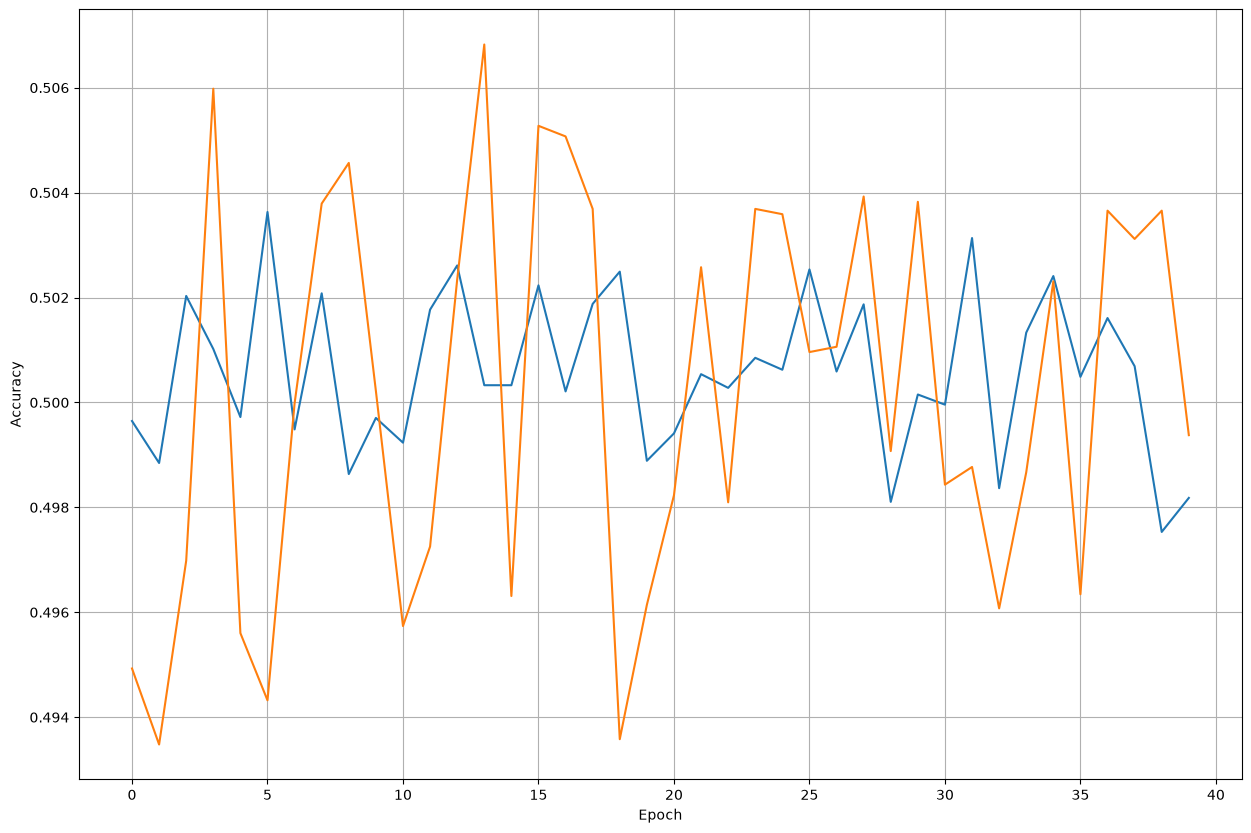

In [53]:
# 학습결과 시각화
plt.figure(figsize=(15, 10))
plt.plot(h.history['accuracy'], label='acc')
plt.plot(h.history['val_accuracy'], label='val_acc')
plt.grid(True)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

### SimpleRNN(바닐라RNN)의 경우 긴 시퀀스를 가진 데이터를 효과적으로 학습하기 어려움
- 순환횟수(시퀀스)가 길어질수록 초반에 입력된 단어의 기억데이터가 소실되는 기울기 소실 현상이 발생함
- 문장 구성 시 초반 단어가 후반 예측에 영향을 주는 경우는 바닐라RNN이 학습하기 어려움

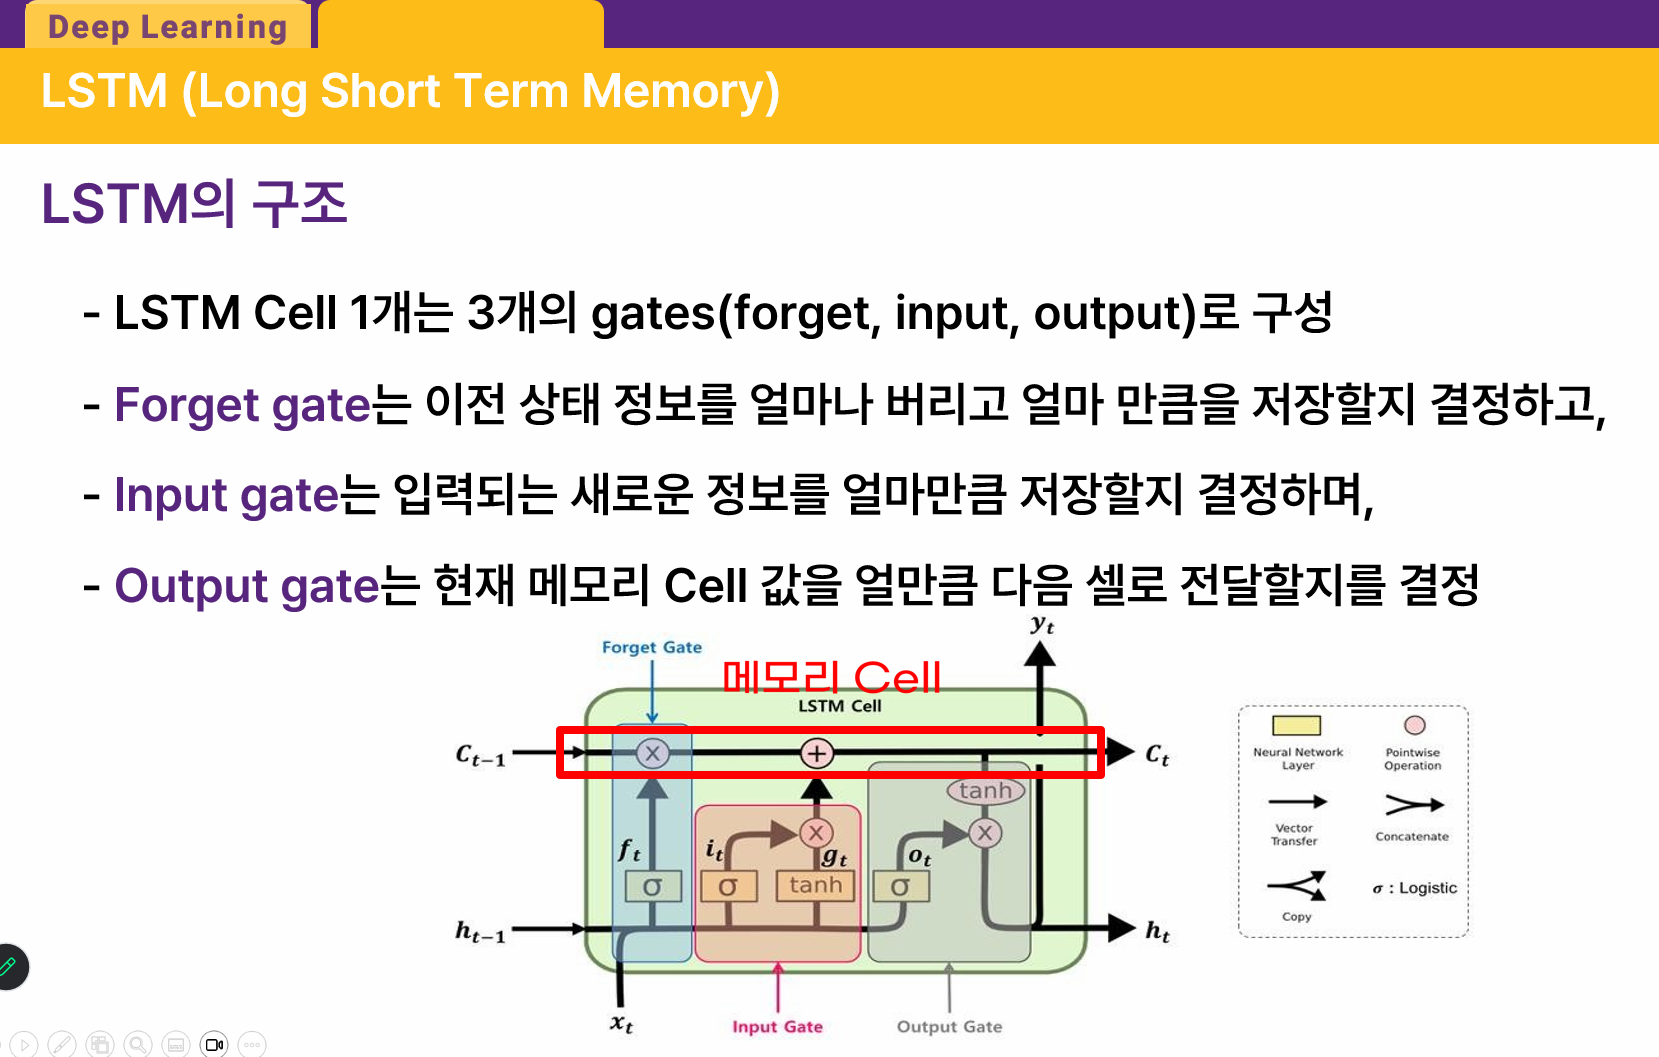

### LSTM(Long Short Term Memory)
- 장기기억과 단기기억을 관리하는 계산이 추가된 구조
- 기존의 RNN구조에서 메모리 셀(Cell)이라는 개념 추가
- 연산이 복잡해져 학습이 오래 걸리고, 모델이 무겁지만 기억손실이 줄어들어 성능 면에서는 RNN보다 좋을 가능성이 높다.


In [55]:
from keras.layers import LSTM
# LSTM : 장기의존성을 처리할 수 있는 rnn의 한종류
# 장기의존성 : 문장이 길어지면 앞에 나온 걸 잘 기억하지 못하더라

In [64]:
# 모델 구조 설계
# 뼈대 생성
lstm_model = Sequential()

# 입력층
lstm_model.add(InputLayer(shape=(30,1)))
# 30번의 순환횟수 (리뷰 1개는 30개의 토큰이 순서대로 입력된다)
# 1번의 순환이 이루어질때 몇개의 정보가 들어가나요 -> 토큰1개는 정수 1개

# 중간층
lstm_model.add(LSTM(units=64))

# 출력층
lstm_model.add(Dense(units=1, activation='sigmoid'))

# 2. 학습 방법 및 평가 방법 설정
lstm_model.compile(
    loss = 'binary_crossentropy',
    optimizer = 'adam',
    metrics = ['accuracy']
)

# 3.학습
h_lstm = lstm_model.fit(
    X_train_vec,
    y_train_clean,
    epochs=40,
    batch_size=128,
    validation_split=0.2,
    callbacks=[GCCallback()]
)

Epoch 1/40
928/928 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.5518 - loss: 0.6826 - val_accuracy: 0.5625 - val_loss: 0.6772
Epoch 2/40
928/928 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.5651 - loss: 0.6768 - val_accuracy: 0.5639 - val_loss: 0.6818
Epoch 3/40
928/928 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.5668 - loss: 0.6751 - val_accuracy: 0.5694 - val_loss: 0.6737
Epoch 4/40
928/928 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.5709 - loss: 0.6714 - val_accuracy: 0.5813 - val_loss: 0.6683
Epoch 5/40
928/928 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.5779 - loss: 0.6677 - val_accuracy: 0.5803 - val_loss: 0.6641
Epoch 6/40
928/928 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.5819 - loss: 0.6642 - val_accuracy: 0.5876 - val_loss: 0.6629
Epoch 7/40
928/928 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.5888 - loss: 0.6611 - val_accuracy: 0.5841 - val_loss: 0.6656
Epoch 8/40
928/928 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.5930 - loss: 0.6579 - 

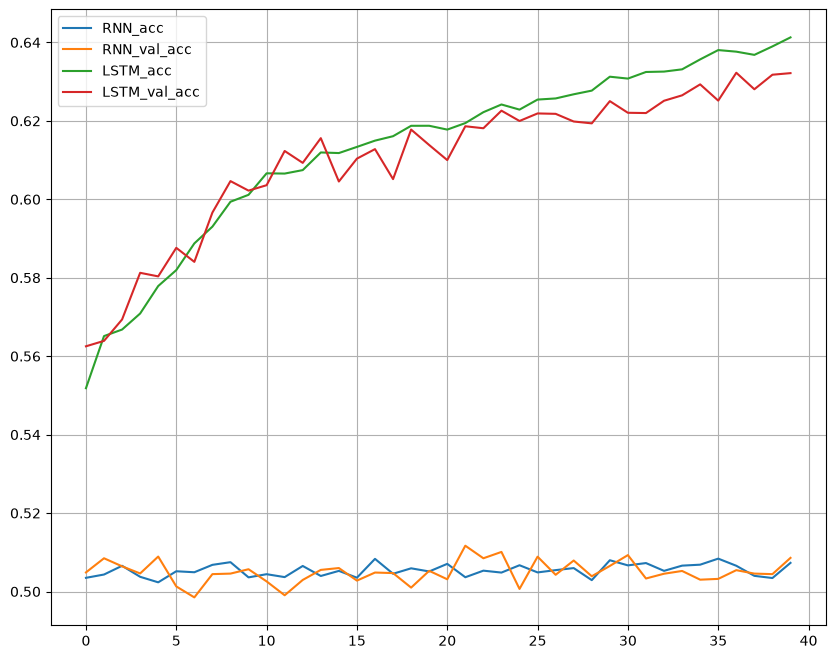

In [65]:
# 결과 시각화
plt.figure(figsize=(10, 8))
# RNN
plt.plot(model.history.history['accuracy'], label='RNN_acc')
plt.plot(model.history.history['val_accuracy'], label='RNN_val_acc')
# LSTM
plt.plot(h_lstm.history['accuracy'], label='LSTM_acc')
plt.plot(h_lstm.history['val_accuracy'], label='LSTM_val_acc')

plt.legend()
plt.grid(True)
plt.show()

### 워드임베딩
- 인공지능기반의 텍스트마이닝, 자연어처리 모델링을 할 때 입력되는 데이터의 수치화 방법도 중요함
- 현재 라벨인코딩 기반의 수치화는 모델이 단어의 빈도 패턴을 학습하는 것과 비슷함
- 단어의 본질적인 의미를 파악할 수 있도록 수치화를 정교하게, 풍성하게 해보자!

In [67]:
pip -q install --upgrade gensim

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [69]:
import gensim.downloader as api
model = api.load("word2vec-google-news-300")

- Records : 레코드의 수, 즉 데이터의 개수를 의미(각 "레코드"는 임베딩된 단어 하나를 의미)

| 모델 이름                           | 레코드 수      | 설명                                                                                                  |
|-------------------------------------|----------------|-------------------------------------------------------------------------------------------------------|
| conceptnet-numberbatch-17-06-300    | 1,917,247      | ConceptNet Numberbatch는 개념 간의 관계를 학습한 모델.                                                 |
|                                     |                | 상식을 이해하고 개념 간 관계를 연결시키기 위해 개발됨.                                                 |
|                                     |                | 주로 의미 네트워크 연구에 사용됨. "고양이"와 "동물" 간의 관계를 학습.                                  |
| fasttext-wiki-news-subwords-300     | 999,999        | fastText는 단어뿐만 아니라 서브워드(단어의 작은 부분)를 학습.                                          |
|                                     |                | "unbelievable"을 "un", "believe", "able"로 나누어 학습.                                                 |
|                                     |                | Wikipedia와 뉴스 기사 데이터를 기반으로 학습됨.                                                       |
| glove-twitter-100                   | 1,193,514      | GloVe는 Stanford에서 개발된 모델로, 단어 간의 공간적 관계를 벡터로 표현.                               |
|                                     |                | 트위터 데이터(2억 개 트윗)로 학습되어 소셜 미디어 자연어 처리 작업에 적합.                             |
| word2vec-google-news-300            | 3,000,000      | Word2Vec은 구글 뉴스 데이터로 학습된 모델.                                                             |
|                                     |                | 뉴스 기사의 단어 간 유사성 및 의미적 관계를 잘 포착.                                                   |
|                                     |                | 뉴스 데이터 기반이기 때문에 자연어 처리에 많이 사용됨.                                                 |
| word2vec-ruscorpora-300             | 184,973        | Word2Vec ruscorpora는 러시아어 텍스트 기반의 모델로,                                                   |
|                                     |                | 러시아어 자연어 처리 작업에 사용됨.                                                                   |
